# Cleaning

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LassoCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

In [108]:
# Insert warehouse name here
warehouse_name = "OE"

base = "~/Lucas_Systems_Capstone_Project"

# Load your processed data
df = pd.read_parquet(f"{base}/data/processed/oe_detailed.parquet")
print(f"Number of rows in original data: {df.shape[0]}")

# Drop missing rows for every variable except UserID, ProductID, UnitOfMeasure
df = df.dropna(subset=['WorkCode', 'AssignmentID', 'ProductID',
       'Quantity', 'Timestamp', 'LocationID', 'Prev_Timestamp',
       'Prev_LocationID', 'Time_Delta_sec', 'ProductCode', 'UnitOfMeasure',
       'Weight', 'Cube', 'Aisle', 'Bay', 'Level', 'Slot', 'Prev_Aisle',
       'Prev_Bay', 'Prev_Level', 'Prev_Slot', 'Aisle2', 'Bay2', 'Prev_Aisle2',
       'Prev_Bay2', 'LocKey', 'PrevLocKey', 'Travel_Distance'])
print(f"Number of rows after removing all missing values: {df.shape[0]}")

# Filter for only Work Code 30
df = df[df["WorkCode"] == "30"]
print(f"Number of rows in work code 30 after removing all missing values: {df.shape[0]}")

Number of rows in original data: 94401
Number of rows after removing all missing values: 91965
Number of rows in work code 30 after removing all missing values: 66284


In [99]:
df['log_Time_Delta_sec'] = np.log1p(df['Time_Delta_sec'])
df['log_Travel_Distance'] = np.log1p(df['Travel_Distance'])
df['log_Weight'] = np.log1p(df['Weight'])
df['log_Cube'] = np.log1p(df['Cube'])

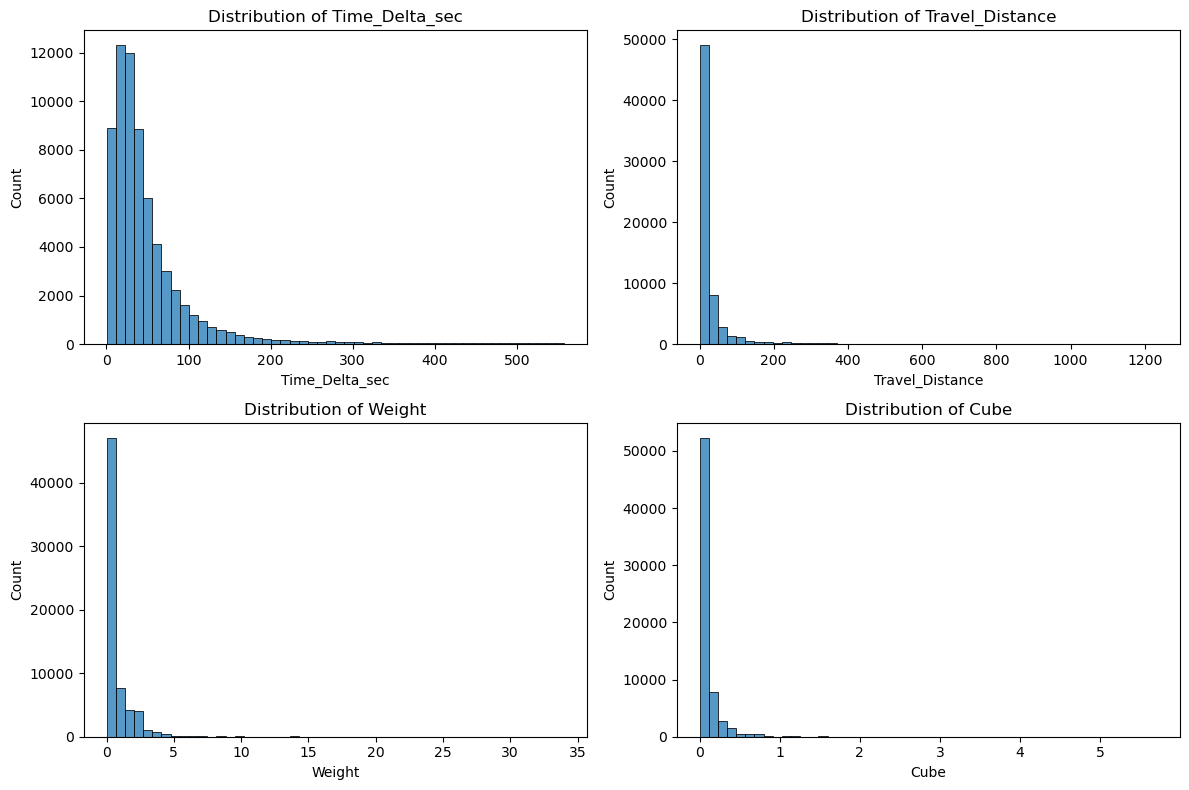

In [100]:
cols = ['Time_Delta_sec', 'Travel_Distance', 'Weight', 'Cube']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), cols):
    sns.histplot(df[col], bins=50, kde=False, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

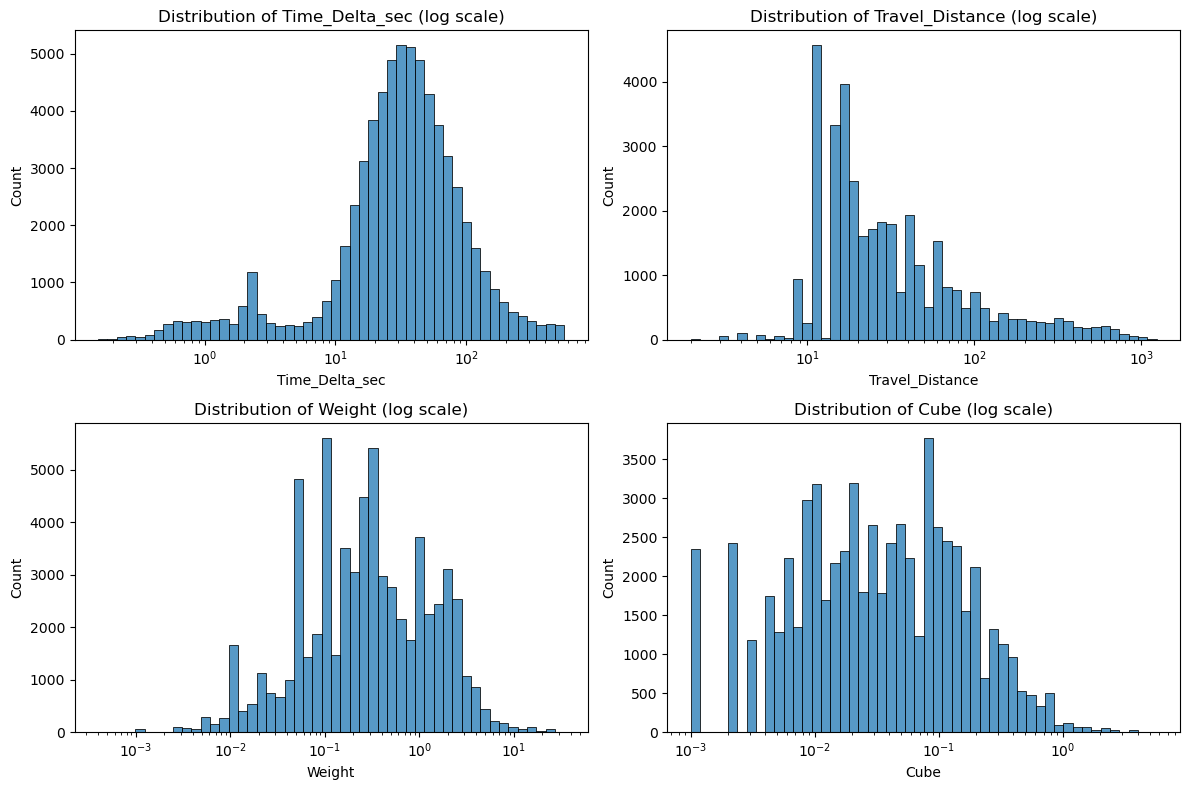

In [101]:
cols = ['Time_Delta_sec', 'Travel_Distance', 'Weight', 'Cube']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), cols):
    sns.histplot(df[col], bins=50, kde=False, ax=ax, log_scale=True)
    ax.set_title(f"Distribution of {col} (log scale)")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# Simple OLS

In [102]:
# 1. Define target (y) and features (X)
target = "log_Time_Delta_sec"
features = ["log_Travel_Distance", "log_Weight", "log_Cube"]

# 2. Extract features and target
X = df[features].astype(float)
y = df[target].astype(float)

# 3. Perform the 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=4)

# 4. Add a constant for the intercept
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# 5. Fit the OLS Model
model = sm.OLS(y_train, X_train_const).fit()
print(model.summary())

# 6. Generate predictions on the test set
pred_log = model.predict(X_test_const)

# 7. Convert values back to original scale (seconds)
# We use expm1 because the data was transformed with log1p
y_test_seconds = np.expm1(y_test)
pred_seconds = np.expm1(pred_log)

# 8. Calculate Metrics
mae_log = mean_absolute_error(y_test, pred_log)
mae_regular = mean_absolute_error(y_test_seconds, pred_seconds)
r2 = r2_score(y_test, pred_log)

print(f"--- Model Evaluation Metrics ---")
print(f"Regular MAE (Seconds):    {mae_regular:.2f}")
print(f"Log-Scale MAE:            {mae_log:.4f}")
print(f"Test R^2:                 {r2:.4f}")

                            OLS Regression Results                            
Dep. Variable:     log_Time_Delta_sec   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     5999.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:19:03   Log-Likelihood:                -72203.
No. Observations:               53027   AIC:                         1.444e+05
Df Residuals:                   53023   BIC:                         1.445e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.9631    

# Lasso OLS

In [ ]:
# 1. Define target (y) and features (X)
target = "log_Time_Delta_sec"
features = ["log_Travel_Distance", "log_Weight", "log_Cube"]

X = df[features].astype(float)
y = df[target].astype(float)

# 2. Perform the 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=4)

# 3. Scale the features
# Lasso is sensitive to the scale of features, so standardization is highly recommended
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Fit Lasso Regression with Cross-Validation
# cv=5 means 5-fold cross-validation
lasso_cv = LassoCV(cv=5, random_state=4)
lasso_cv.fit(X_train_scaled, y_train)

# 5. Generate predictions on the test set
pred_log = lasso_cv.predict(X_test_scaled)

# 6. Convert values back to original scale (seconds)
y_test_seconds = np.expm1(y_test)
pred_seconds = np.expm1(pred_log)

# 7. Calculate Metrics
mae_log = mean_absolute_error(y_test, pred_log)
mae_regular = mean_absolute_error(y_test_seconds, pred_seconds)
rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))
r2 = r2_score(y_test, pred_log)

print(f"--- Lasso CV Model Evaluation ---")
print(f"Best Alpha Found:         {lasso_cv.alpha_:.6f}")
print(f"Regular MAE (Seconds):    {mae_regular:.2f}")
print(f"Log-Scale MAE:            {mae_log:.4f}")
print(f"Test R^2:                 {r2:.4f}")

# Optional: View coefficients
coef_table = pd.DataFrame({
    "Variable": features,
    "Coefficient": lasso_cv.coef_
})
print("\n--- Model Coefficients ---")
print(coef_table)

--- Lasso CV Model Evaluation ---
Best Alpha Found:         0.000544
Regular MAE (Seconds):    31.17
Log-Scale MAE:            0.7276
Log-Scale RMSE:           0.9397
Test R^2:                 0.2589

--- Model Coefficients ---
              Variable  Coefficient
0  log_Travel_Distance     0.548105
1           log_Weight    -0.033623
2             log_Cube    -0.052990


# Decision Tree

In [104]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define target (y) and features (X) using regular (non-log) variables
target = "Time_Delta_sec"
features = ["Travel_Distance", "Weight", "Cube"]

X = df[features].astype(float)
y = df[target].astype(float)

# 2. Perform the 80/20 train-test split (as previously requested)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=4)

# 3. Initialize the Decision Tree Regressor
dtree = DecisionTreeRegressor(random_state=4)

# 4. Define the parameter grid for Cross-Validation
# We'll test different depths and leaf sizes to find the best fit
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 5. Use GridSearchCV to find the optimal parameters
# cv=5 indicates 5-fold cross-validation
# scoring='neg_mean_absolute_error' aligns with your preference for MAE
grid_search = GridSearchCV(estimator=dtree, param_grid=param_grid, 
                           cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

grid_search.fit(X_train, y_train)

# 6. Get the best model
best_dtree = grid_search.best_estimator_

# 7. Generate predictions on the test set
predictions = best_dtree.predict(X_test)

# 8. Calculate Metrics
# Since the variables aren't logged, these are already in regular units (seconds)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"--- Decision Tree (CV Optimized) Evaluation ---")
print(f"Best Parameters:          {grid_search.best_params_}")
print(f"Regular MAE (Seconds):    {mae:.2f}")
print(f"Test R^2:                 {r2:.4f}")

# Optional: View feature importance to see which variable drove the tree
importance = pd.DataFrame({
    "Feature": features,
    "Importance": best_dtree.feature_importances_
}).sort_values(by="Importance", ascending=False)
print("\n--- Feature Importances ---")
print(importance)

--- Decision Tree (CV Optimized) Evaluation ---
Best Parameters:          {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Regular MAE (Seconds):    31.73
Test R^2:                 0.2588

--- Feature Importances ---
           Feature  Importance
0  Travel_Distance    0.824908
1           Weight    0.093010
2             Cube    0.082082


# XG Boost

In [106]:
# 1. Define target (y) and features (X) using regular units
target = "Time_Delta_sec"
features = ["Travel_Distance", "Weight", "Cube"]

X = df[features].astype(float)
y = df[target].astype(float)

# 2. Perform the 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=4)

# 3. Initialize and Fit the XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    objective="reg:gamma", # Can be changed to "reg:gamma" for skewed data
    tree_method="hist",           # Optimizes training speed
    n_jobs=-1,                    # Uses all available CPU cores
    random_state=4
)

xgb_model.fit(X_train, y_train)

# 4. Generate Predictions
predictions = xgb_model.predict(X_test)

# 5. Calculate Metrics (Regular Scale in Seconds)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"--- XGBoost Model Evaluation ---")
print(f"Regular MAE (Seconds):    {mae:.2f}")
print(f"Test R^2:                 {r2:.4f}")

# 6. Feature Importance
importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n--- Feature Importances ---")
print(importance)

--- XGBoost Model Evaluation ---
Regular MAE (Seconds):    30.02
Test R^2:                 0.2946

--- Feature Importances ---
           Feature  Importance
0  Travel_Distance    0.692034
2             Cube    0.170310
1           Weight    0.137655


# kNN

In [105]:
# 1. Define target and features using regular (non-log) variables
target = "Time_Delta_sec"
features = ["Travel_Distance", "Weight", "Cube"]

X = df[features].astype(float)
y = df[target].astype(float)

# 2. Perform the 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=4)

# 3. Scale the features (CRITICAL for kNN)
# kNN relies on distance; without scaling, large units will dominate the model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize the kNN Regressor
knn = KNeighborsRegressor()

# 5. Define the parameter grid for Cross-Validation
# We test different k values (n_neighbors) to find the optimal balance
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],  # 'distance' weights closer neighbors more heavily
    'metric': ['euclidean', 'manhattan'] # Different ways to calculate 'distance'
}

# 6. Use GridSearchCV to find the optimal kNN parameters
# We use neg_mean_absolute_error to prioritize your preferred metric
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, 
                           cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

# 7. Get the best model
best_knn = grid_search.best_estimator_

# 8. Generate predictions on the test set
predictions = best_knn.predict(X_test_scaled)

# 9. Calculate Metrics (Regular Scale in Seconds)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"--- kNN (CV Optimized) Evaluation ---")
print(f"Best Parameters:          {grid_search.best_params_}")
print(f"Regular MAE (Seconds):    {mae:.2f}")
print(f"Test R^2:                 {r2:.4f}")

--- kNN (CV Optimized) Evaluation ---
Best Parameters:          {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}
Regular MAE (Seconds):    31.47
Test R^2:                 0.2433


# Neural Network

In [107]:
# 1. Prepare Data (using the regular variables)
features = ['Travel_Distance', 'Weight', 'Cube']
target = 'Time_Delta_sec'

X = df[features].values.astype(np.float32)
y = df[target].values.astype(np.float32)

# 2. 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# 3. Scaling (Essential for neural network performance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Define Model
# Input layer adjusted to 3 for your features
model = nn.Sequential(
    nn.Linear(3, 500),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(500, 200),
    nn.Dropout(0.2),
    nn.ReLU(),
    nn.Linear(200, 25),
    nn.ReLU(),
    nn.Linear(25, 1)
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# 5. Prepare Tensors and DataLoaders
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 6. Training Loop (with gradient clipping)
for epoch in range(10):
    model.train()
    for inputs, labels in train_loader:
        # Flatten if needed
        inputs = inputs.view(inputs.size(0), -1)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# 7. Evaluation (using L1Loss for MAE)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model.eval()
test_criterion = nn.L1Loss() # Switch to L1 for MAE calculation
test_loss = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.view(inputs.size(0), -1)
        outputs = model(inputs)
        loss = test_criterion(outputs, labels)
        test_loss += loss.item()

avg_mae = test_loss / len(test_loader)
print(f"\n--- Model Evaluation ---")
print(f"Test MAE (Seconds): {avg_mae:.4f}")

Epoch 1, Loss: 2608.1914
Epoch 2, Loss: 1775.6366
Epoch 3, Loss: 1495.7272
Epoch 4, Loss: 1178.7284
Epoch 5, Loss: 1217.2983
Epoch 6, Loss: 3776.4634
Epoch 7, Loss: 9067.0732
Epoch 8, Loss: 835.8365
Epoch 9, Loss: 4047.0562
Epoch 10, Loss: 1931.3763

--- Model Evaluation ---
Test MAE (Seconds): 32.2151
